In [35]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

In [36]:
img = plt.imread("Bikesgray.png")

In [37]:
img.shape

(480, 640)

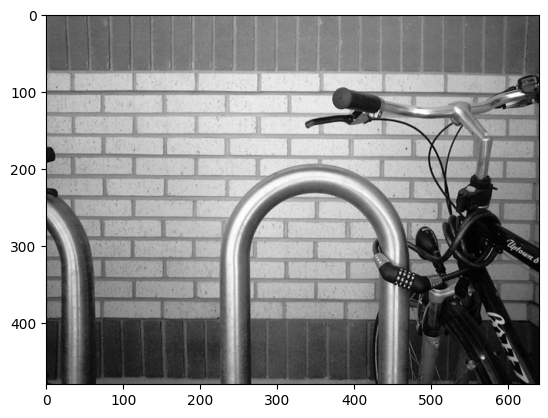

In [38]:
plt.imshow(img,cmap = "Greys_r")

In [39]:
def apply_filter(image,filter):
    h,w = image.shape
    fh,fv = filter.shape
    newimage = np.zeros((h - fh + 1, w - fv + 1))
    for i in range(h - fh + 1):
        for j in range(w - fv + 1):
            newimage[i,j] = np.sum(image[i:(i + fh),j:(j + fv)] * filter , axis = (0,1))
    return newimage

In [40]:
filter_size = 11
filterv = np.zeros((filter_size,filter_size))
filterh = np.zeros((filter_size,filter_size))
filterv[:,filter_size//2 + 1] = 1
filterh[filter_size//2 + 1,:] = 1

In [41]:
imgv = apply_filter(img,filterv)
imgh = apply_filter(img,filterh)

In [42]:
def plot(img,imgv,imgh):
    plt.figure(figsize = (12,6))
    plt.subplot(1,3,1)
    plt.imshow(img,cmap = "Greys_r")
    plt.title("Original Image")
    plt.subplot(1,3,2)
    plt.imshow(imgv,cmap = "Greys_r")
    plt.title("Vertical Edges")
    plt.subplot(1,3,3)
    plt.imshow(imgh,cmap = "Greys_r")
    plt.title("Horizontal Edges")
    plt.show()

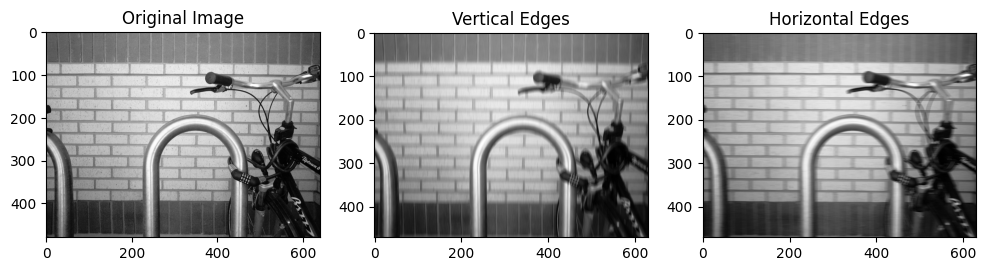

In [43]:
plot(img,imgv,imgh)

In [44]:
imgv = apply_filter(img,filterv)
imgh = apply_filter(img,filterh)

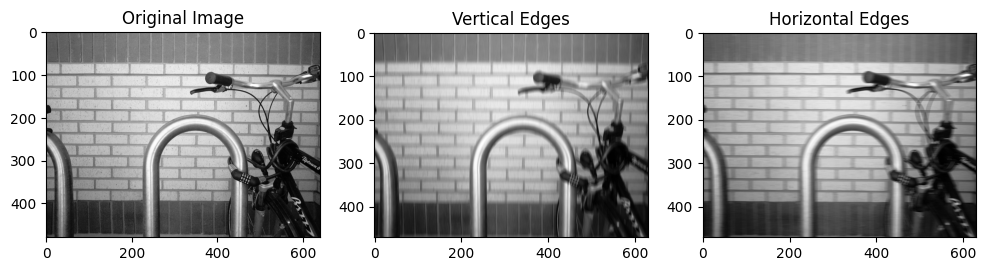

In [45]:
plot(img,imgv,imgh)

In [46]:
sobelv = np.array([[-1,0,1],
                   [-2,0,2],
                   [-1,0,1]])
sobelh = np.array([[1,2,1],
                   [0,0,0],
                   [-1,-2,-1]])

In [47]:
imgv = apply_filter(img,sobelv)
imgh = apply_filter(img,sobelh)

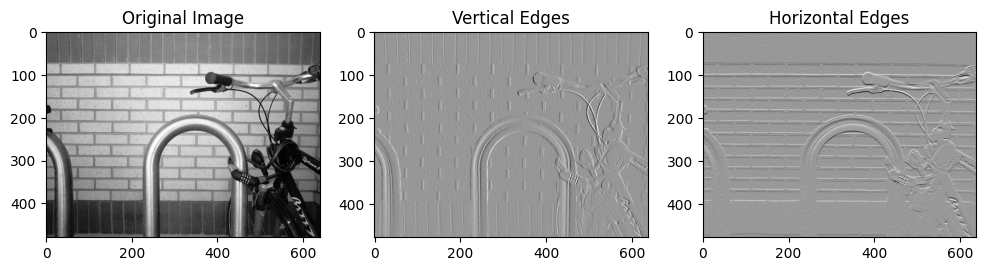

In [48]:
plot(img,imgv,imgh)

In [49]:
import os
from tensorflow import keras

In [50]:
trainData = pd.read_csv("mnist_train.zip")
testData = pd.read_csv("mnist_test.zip")
Xtrain , Ytrain = trainData.iloc[:,1:].to_numpy(),trainData.iloc[:,0].to_numpy()
Xtest , Ytest = testData.iloc[:,1:].to_numpy(),testData.iloc[:,0].to_numpy()
Xtrain,Xtest = Xtrain.reshape(-1,28,28),Xtest.reshape(-1,28,28)
Xtrain = Xtrain.astype("float32")/255
Xtest = Xtest.astype("float32")/255

In [51]:
Xtrain.shape

(59999, 28, 28)

In [52]:
from keras.utils import to_categorical
Ytrain = to_categorical(Ytrain, 10)
Ytest = to_categorical(Ytest, 10)

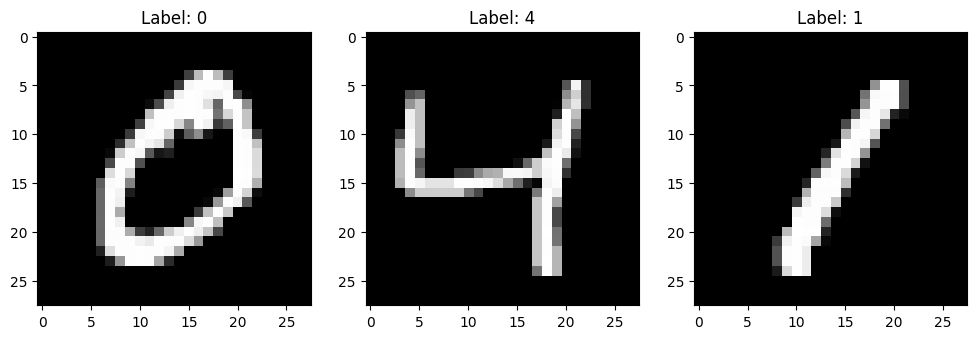

In [53]:
plt.figure(figsize = (12,4))
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(Xtrain[i],cmap = "Greys_r")
    plt.title(f"Label: {np.argmax(Ytrain[i])}")
plt.show()

## Model 1

In [54]:
from keras.layers import Input,Conv2D,Dense,Flatten,MaxPooling2D
num_filterers = 8
filter_size = (3,3)
pool_size = (2,2)
model = keras.Sequential([
    Input(shape = (*Xtrain.shape[1:],1 )),
    Conv2D(num_filterers,filter_size,activation = "relu"),
    MaxPooling2D(pool_size = pool_size),
    Flatten(),
    Dense(10,activation = "softmax")
])
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        13,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,610 (53.16 KB)

 Trainable params: 13,610 (53.16 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss=keras.losses.CategoricalCrossentropy(),
              metrics=[keras.metrics.CategoricalAccuracy(name="accuracy")])

In [56]:
history = model.fit(Xtrain, Ytrain,
                    validation_split=0.15,
                    batch_size=128,
                    epochs=20,
                    shuffle=True)

Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8553 - loss: 0.5269 - val_accuracy: 0.9269 - val_loss: 0.2554
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9259 - loss: 0.2545 - val_accuracy: 0.9470 - val_loss: 0.1924
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9438 - loss: 0.1960 - val_accuracy: 0.9577 - val_loss: 0.1555
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9543 - loss: 0.1600 - val_accuracy: 0.9639 - val_loss: 0.1334
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9607 - loss: 0.1363 - val_accuracy: 0.9667 - val_loss: 0.1177
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9657 - loss: 0.1198 - val_accuracy: 0.9694 - val_loss: 0.1098
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9695 - loss: 0.1068 - val_accuracy: 0.9736 - val_loss: 0.0985
Epoch 8/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9726 - loss: 0.0957 - val_accuracy: 0.

In [57]:
def plot_results(history):
    fig, ax = plt.subplots(1,2, figsize=(12,5))
    
    # Plot loss
    ax[0].plot(history.history['loss'], label='Training Loss')
    ax[0].plot(history.history['val_loss'], label='Validation Loss')
    ax[0].set_title('Loss over Epochs')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss')
    ax[0].legend()
    ax[0].grid(True)
    
    # Plot accuracy
    ax[1].plot(history.history['accuracy'], label='Training Accuracy')
    ax[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax[1].set_title('Accuracy over Epochs')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Accuracy')
    ax[1].legend()
    ax[1].grid(True)
    
    plt.show()

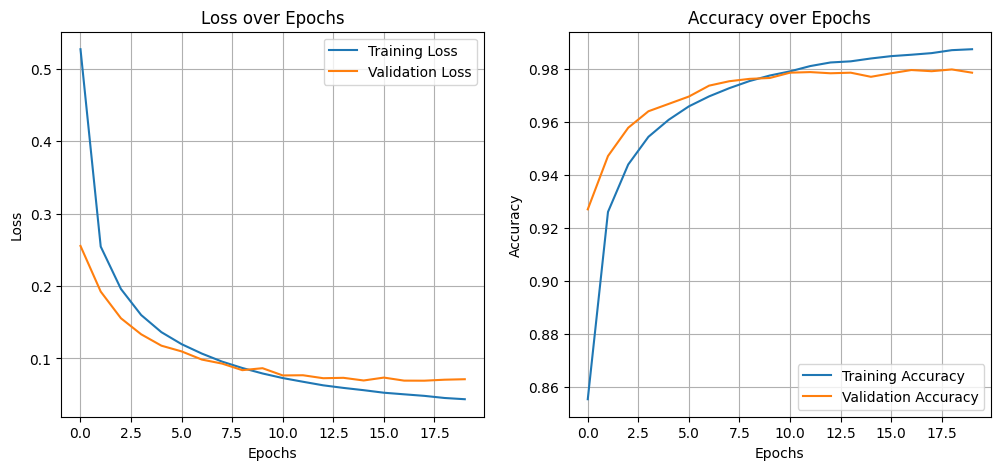

In [58]:
plot_results(history)

In [59]:
# get the first Conv2D layer (handles presence of an Input layer) and read its weights
conv_layer = next(layer for layer in model.layers if isinstance(layer, Conv2D))
w = conv_layer.get_weights()[0]

In [60]:
w.shape

(3, 3, 1, 8)

In [61]:
w[:,:,0,0]

array([[ 0.6325842 , -0.4069669 , -1.5997455 ],
       [ 0.9661679 ,  0.4340219 , -0.8355615 ],
       [ 0.42207024,  0.5852994 ,  0.15639178]], dtype=float32)

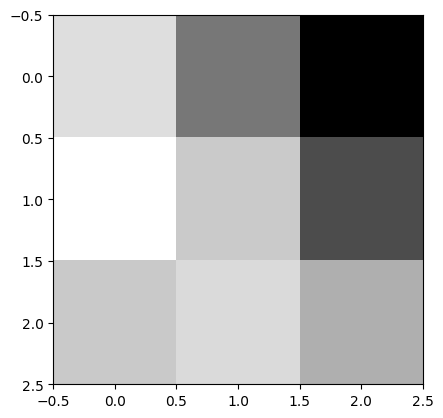

In [62]:
plt.imshow(w[:,:,0,0],cmap = "gray")

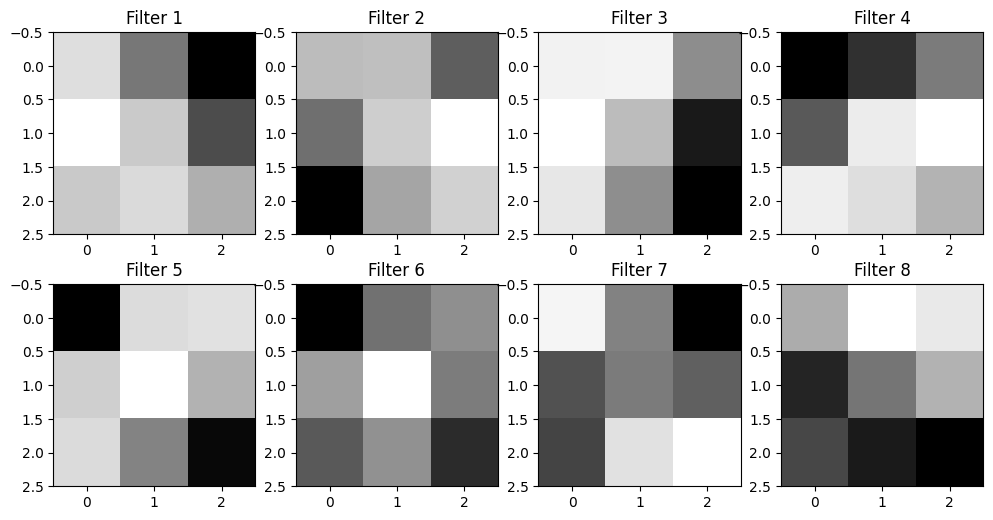

In [63]:
fig,ax = plt.subplots(2,4, figsize = (12,6))
for i in range(2):
    for j in range(4):
        ax[i,j].imshow(w[:,:,0,i*4 + j],cmap = "gray")
        ax[i,j].set_title(f"Filter {i*4 + j + 1}")

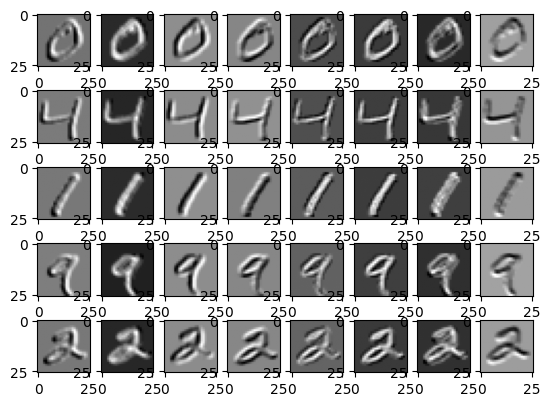

In [64]:
fig, ax = plt.subplots(5, 8)
for j in range(5):
    for i in range(8):
        ax[j, i].imshow(apply_filter(Xtrain[j, :, :], w[:, :, 0, i]), cmap="gray")

## Model 2

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 5)      │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 13, 13, 5)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 845)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         8,460 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,510 (33.24 KB)

 Trainable params: 8,510 (33.24 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8365 - loss: 0.6111 - val_accuracy: 0.9179 - val_loss: 0.2879
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9105 - loss: 0.3072 - val_accuracy: 0.9256 - val_loss: 0.2589
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9212 - loss: 0.2744 - val_accuracy: 0.9334 - val_loss: 0.2336
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9302 - loss: 0.2417 - val_accuracy: 0.9407 - val_loss: 0.2113
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9403 - loss: 0.2102 - val_accuracy: 0.9501 - val_loss: 0.1828
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9475 - loss: 0.1825 - val_accuracy: 0.9559 - val_loss: 0.1600
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9555 - loss: 0.1582 - val_accuracy: 0.9617 - val_loss: 0.1410
Epoch 8/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9603 - loss: 0.1398 - val_accuracy: 0.

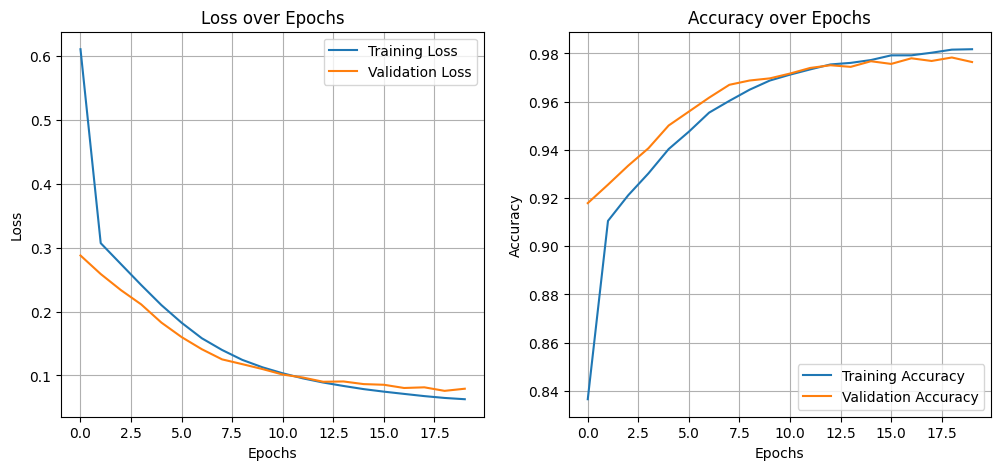

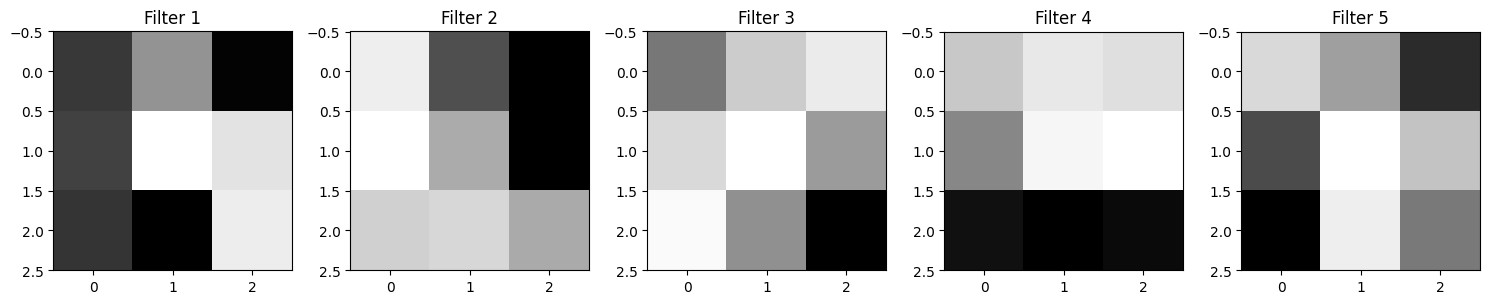

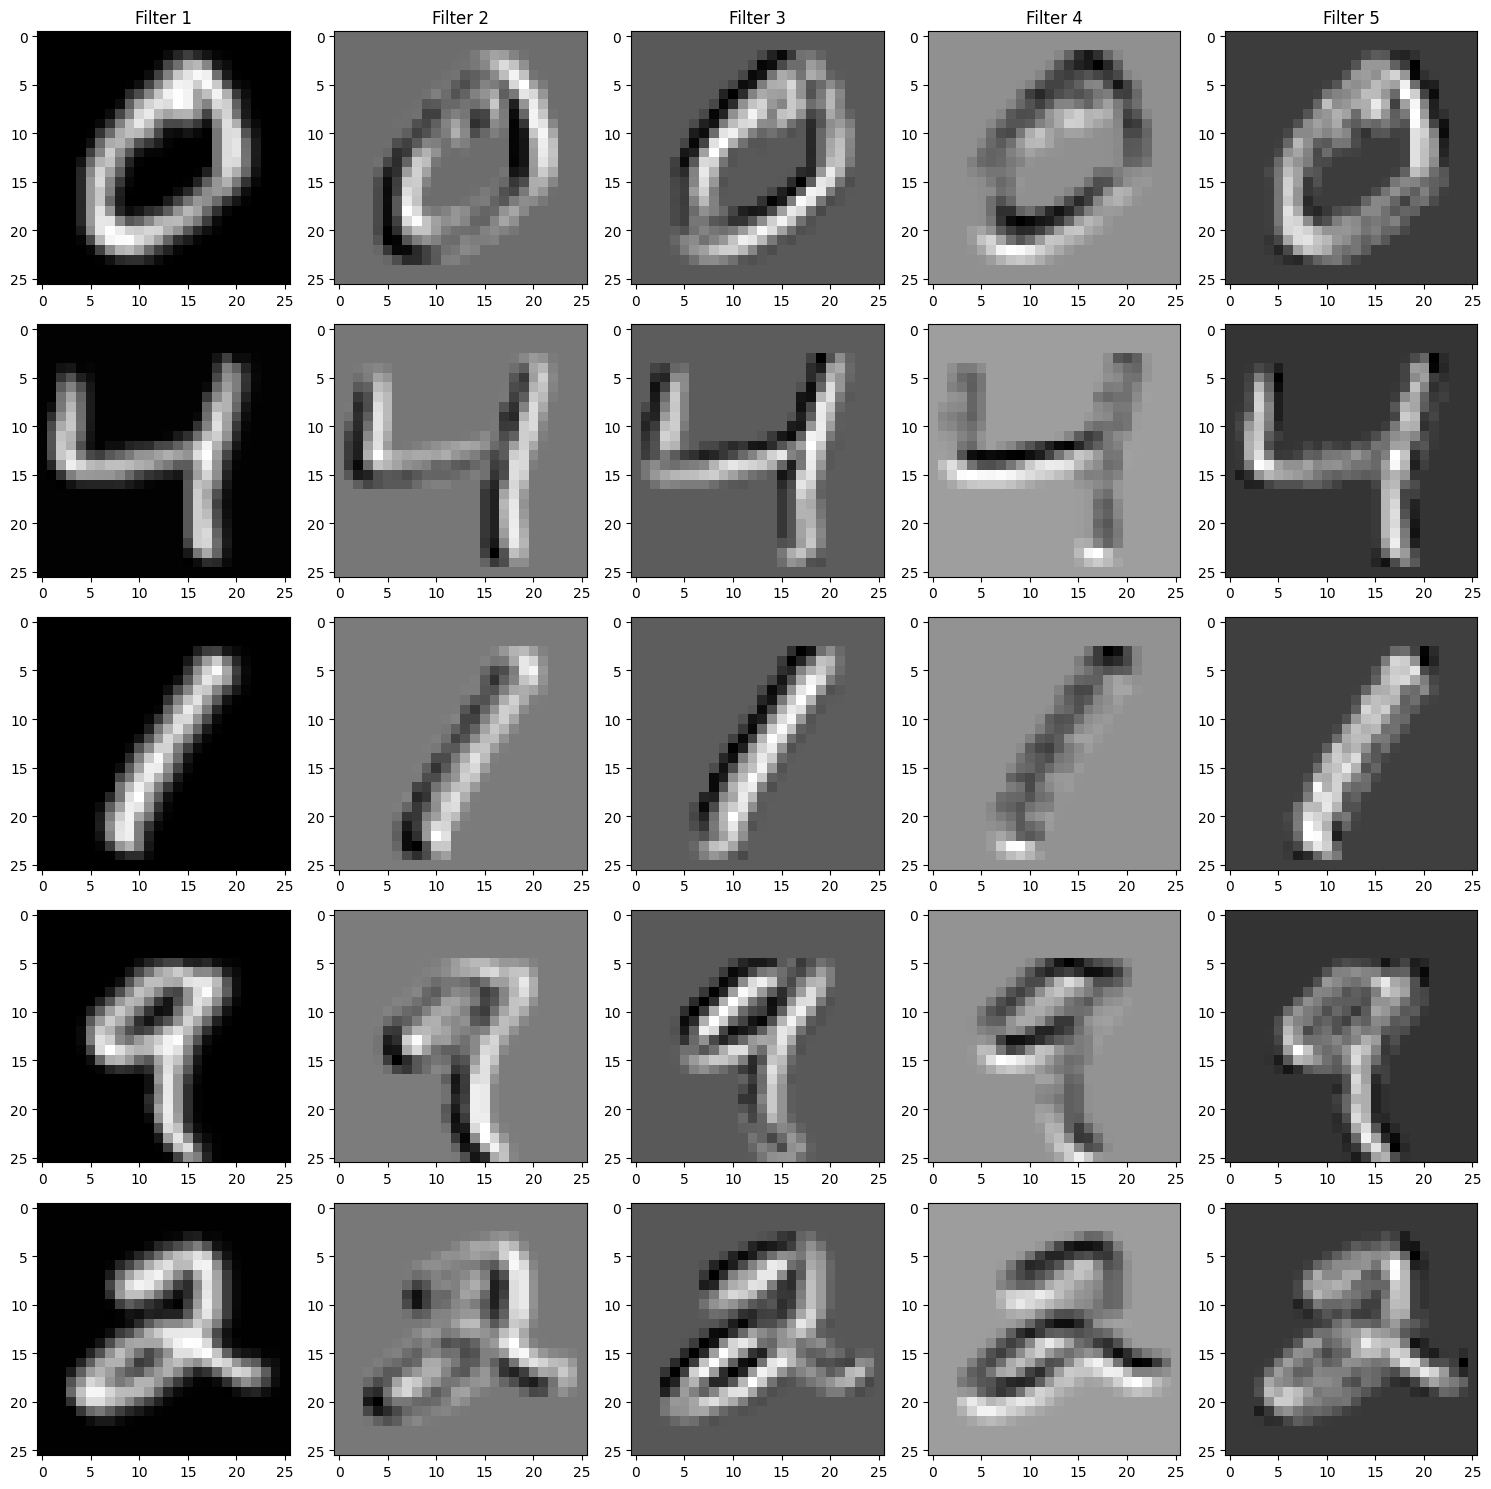

In [65]:
num_filterers = 5
filter_size = (3,3)
pool_size = (2,2)
model = keras.Sequential([
    Input(shape = (*Xtrain.shape[1:],1 )),
    Conv2D(num_filterers,filter_size,activation = "relu"),
    MaxPooling2D(pool_size = pool_size),
    Flatten(),
    Dense(10,activation = "softmax")
])
model.summary()
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss=keras.losses.CategoricalCrossentropy(),
              metrics=[keras.metrics.CategoricalAccuracy(name="accuracy")])
history = model.fit(Xtrain, Ytrain,
                    validation_split=0.15,
                    batch_size=128,
                    epochs=20,
                    shuffle=True)
plot_results(history)

conv_layer = next(layer for layer in model.layers if isinstance(layer, Conv2D))
w = conv_layer.get_weights()[0]

# visualize convolutional filters (handles any number of filters)
n_filters = w.shape[-1]
cols = min(8, n_filters)
rows = (n_filters + cols - 1) // cols
fig, ax = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
ax = np.array(ax).reshape(rows, cols)
for idx in range(n_filters):
    r = idx // cols
    c = idx % cols
    ax[r, c].imshow(w[:, :, 0, idx], cmap="gray")
    ax[r, c].set_title(f"Filter {idx+1}")
# hide unused axes
for idx in range(n_filters, rows*cols):
    r = idx // cols
    c = idx % cols
    ax[r, c].axis('off')
plt.tight_layout()

# apply filters to a few training samples and display results (adjusts to available filters)
n_samples = min(5, Xtrain.shape[0])
cols = n_filters
rows = n_samples
fig, ax = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
for j in range(rows):
    for i in range(cols):
        filtered = apply_filter(Xtrain[j, :, :], w[:, :, 0, i])
        ax[j, i].imshow(filtered, cmap="gray")
        if j == 0:
            ax[j, i].set_title(f"Filter {i+1}")
plt.tight_layout()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 8)      │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │        11,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,738 (45.85 KB)

 Trainable params: 11,738 (45.85 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8725 - loss: 0.4688 - val_accuracy: 0.9462 - val_loss: 0.1973
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9481 - loss: 0.1795 - val_accuracy: 0.9607 - val_loss: 0.1409
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9636 - loss: 0.1278 - val_accuracy: 0.9720 - val_loss: 0.1051
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9704 - loss: 0.1037 - val_accuracy: 0.9761 - val_loss: 0.0866
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9752 - loss: 0.0878 - val_accuracy: 0.9761 - val_loss: 0.0850
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9778 - loss: 0.0768 - val_accuracy: 0.9799 - val_loss: 0.0755
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9802 - loss: 0.0687 - val_accuracy: 0.9806 - val_loss: 0.0741
Epoch 8/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9815 - loss: 0.0627 - val_accuracy: 0.

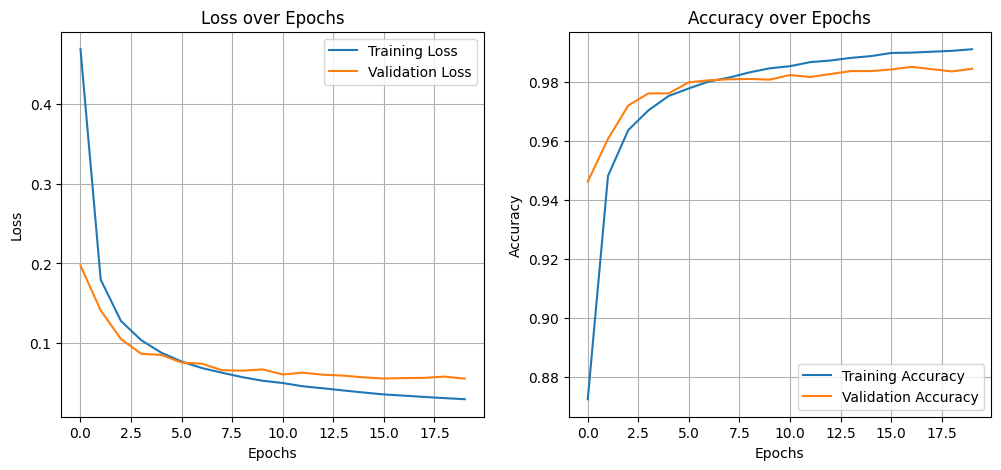

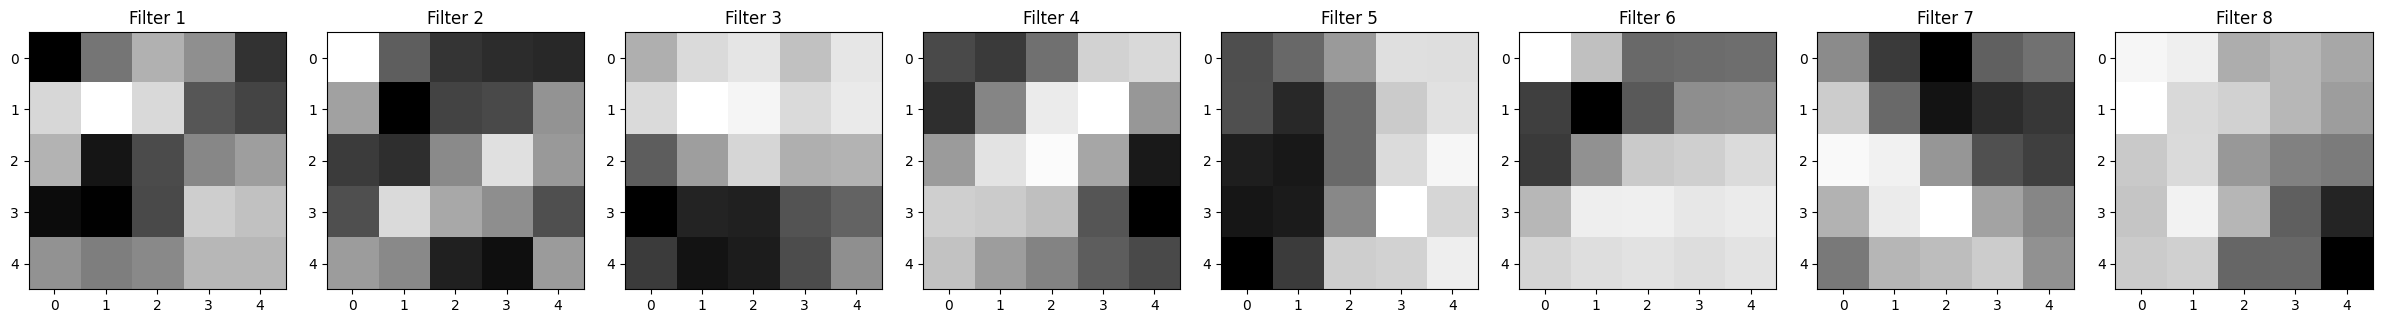

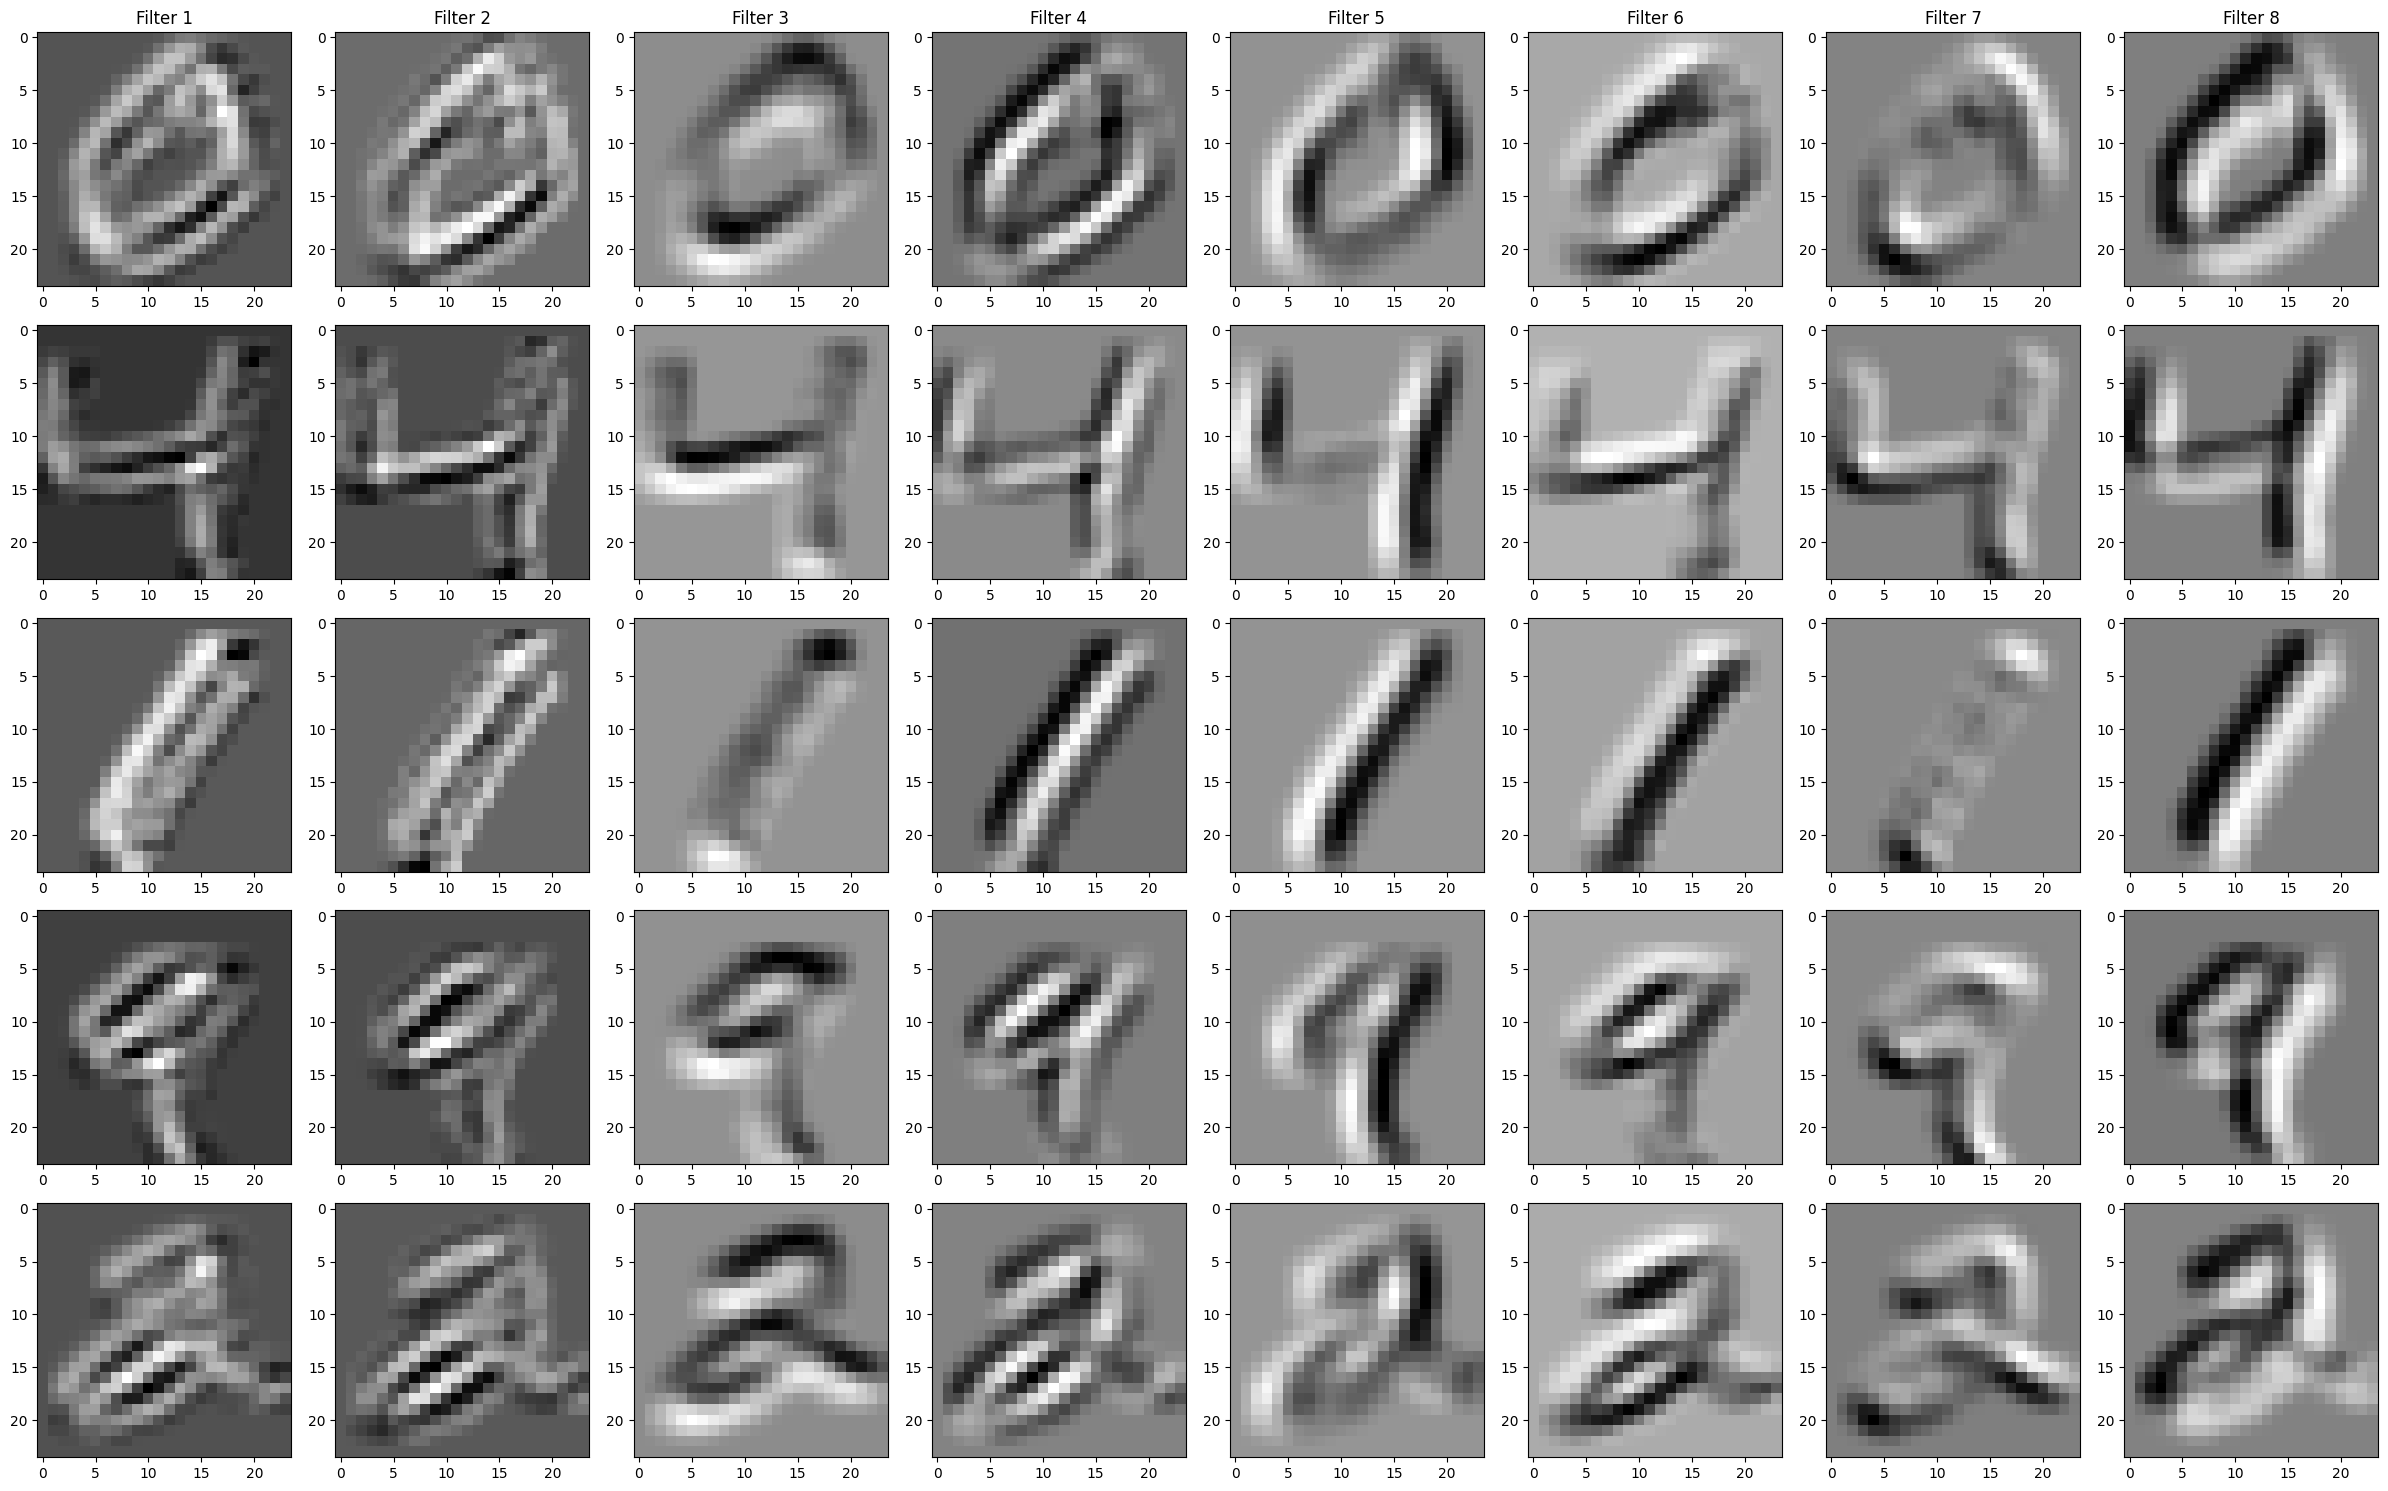

In [66]:
num_filterers = 8
filter_size = (5,5)
pool_size = (2,2)
model = keras.Sequential([
    Input(shape = (*Xtrain.shape[1:],1 )),
    Conv2D(num_filterers,filter_size,activation = "relu"),
    MaxPooling2D(pool_size = pool_size),
    Flatten(),
    Dense(10,activation = "softmax")
])
model.summary()
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss=keras.losses.CategoricalCrossentropy(),
              metrics=[keras.metrics.CategoricalAccuracy(name="accuracy")])
history = model.fit(Xtrain, Ytrain,
                    validation_split=0.15,
                    batch_size=128,
                    epochs=20,
                    shuffle=True)
plot_results(history)

conv_layer = next(layer for layer in model.layers if isinstance(layer, Conv2D))
w = conv_layer.get_weights()[0]

n_filters = w.shape[-1]
cols = min(8, n_filters)
rows = (n_filters + cols - 1) // cols
fig, ax = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
ax = np.array(ax).reshape(rows, cols)
for idx in range(n_filters):
    r = idx // cols
    c = idx % cols
    ax[r, c].imshow(w[:, :, 0, idx], cmap="gray")
    ax[r, c].set_title(f"Filter {idx+1}")
for idx in range(n_filters, rows*cols):
    r = idx // cols
    c = idx % cols
    ax[r, c].axis('off')
plt.tight_layout()

n_samples = min(5, Xtrain.shape[0])
cols = n_filters
rows = n_samples
fig, ax = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
for j in range(rows):
    for i in range(cols):
        filtered = apply_filter(Xtrain[j, :, :], w[:, :, 0, i])
        ax[j, i].imshow(filtered, cmap="gray")
        if j == 0:
            ax[j, i].set_title(f"Filter {i+1}")
plt.tight_layout()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,890 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,970 (11.60 KB)

 Trainable params: 2,970 (11.60 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7389 - loss: 0.9244 - val_accuracy: 0.8931 - val_loss: 0.3677
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8990 - loss: 0.3418 - val_accuracy: 0.9287 - val_loss: 0.2495
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9239 - loss: 0.2562 - val_accuracy: 0.9388 - val_loss: 0.2048
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9379 - loss: 0.2106 - val_accuracy: 0.9496 - val_loss: 0.1721
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9461 - loss: 0.1807 - val_accuracy: 0.9574 - val_loss: 0.1505
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9527 - loss: 0.1590 - val_accuracy: 0.9616 - val_loss: 0.1358
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9577 - loss: 0.1429 - val_accuracy: 0.9653 - val_loss: 0.1244
Epoch 8/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9618 - loss: 0.1307 - val_accuracy:

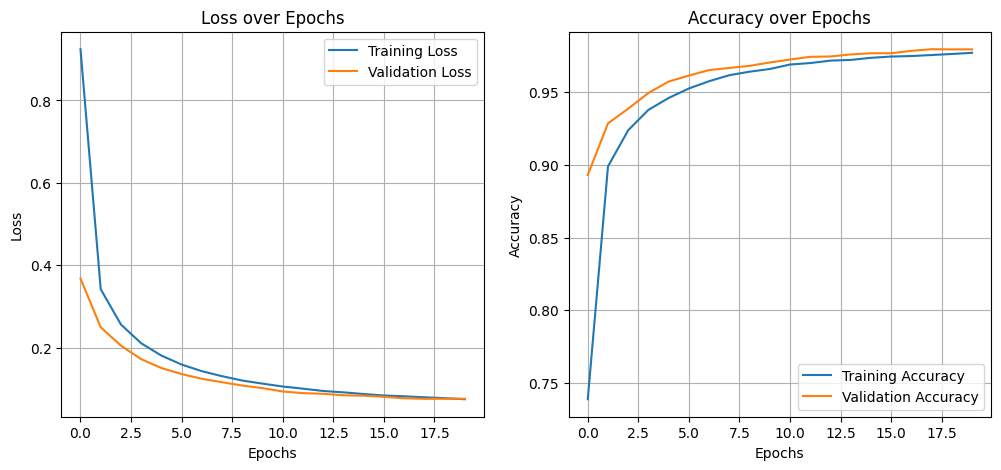

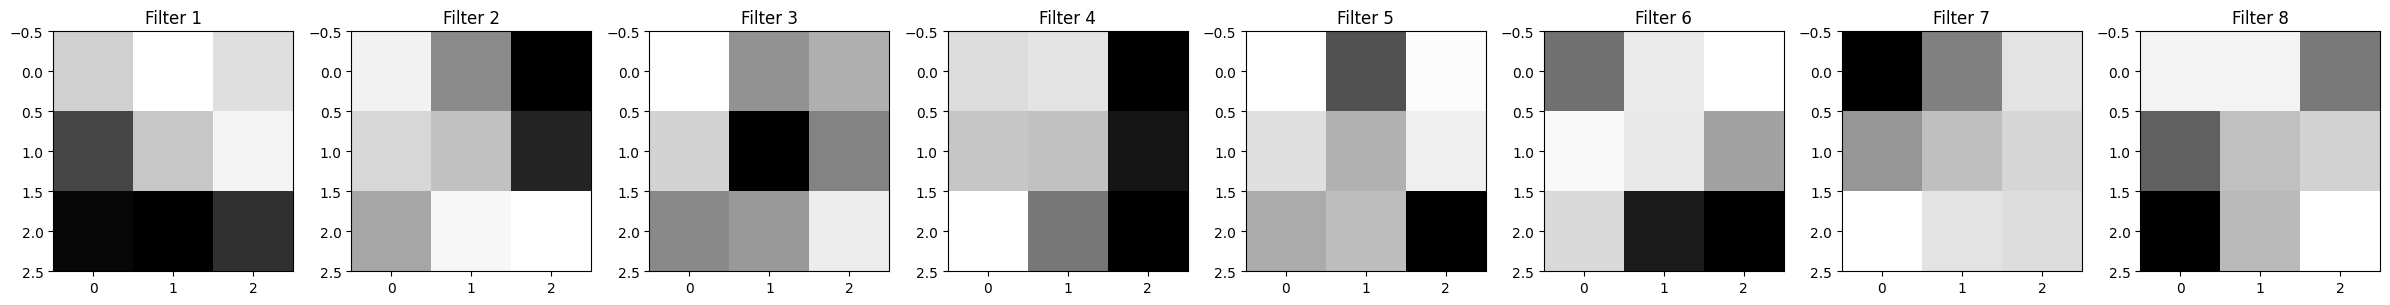

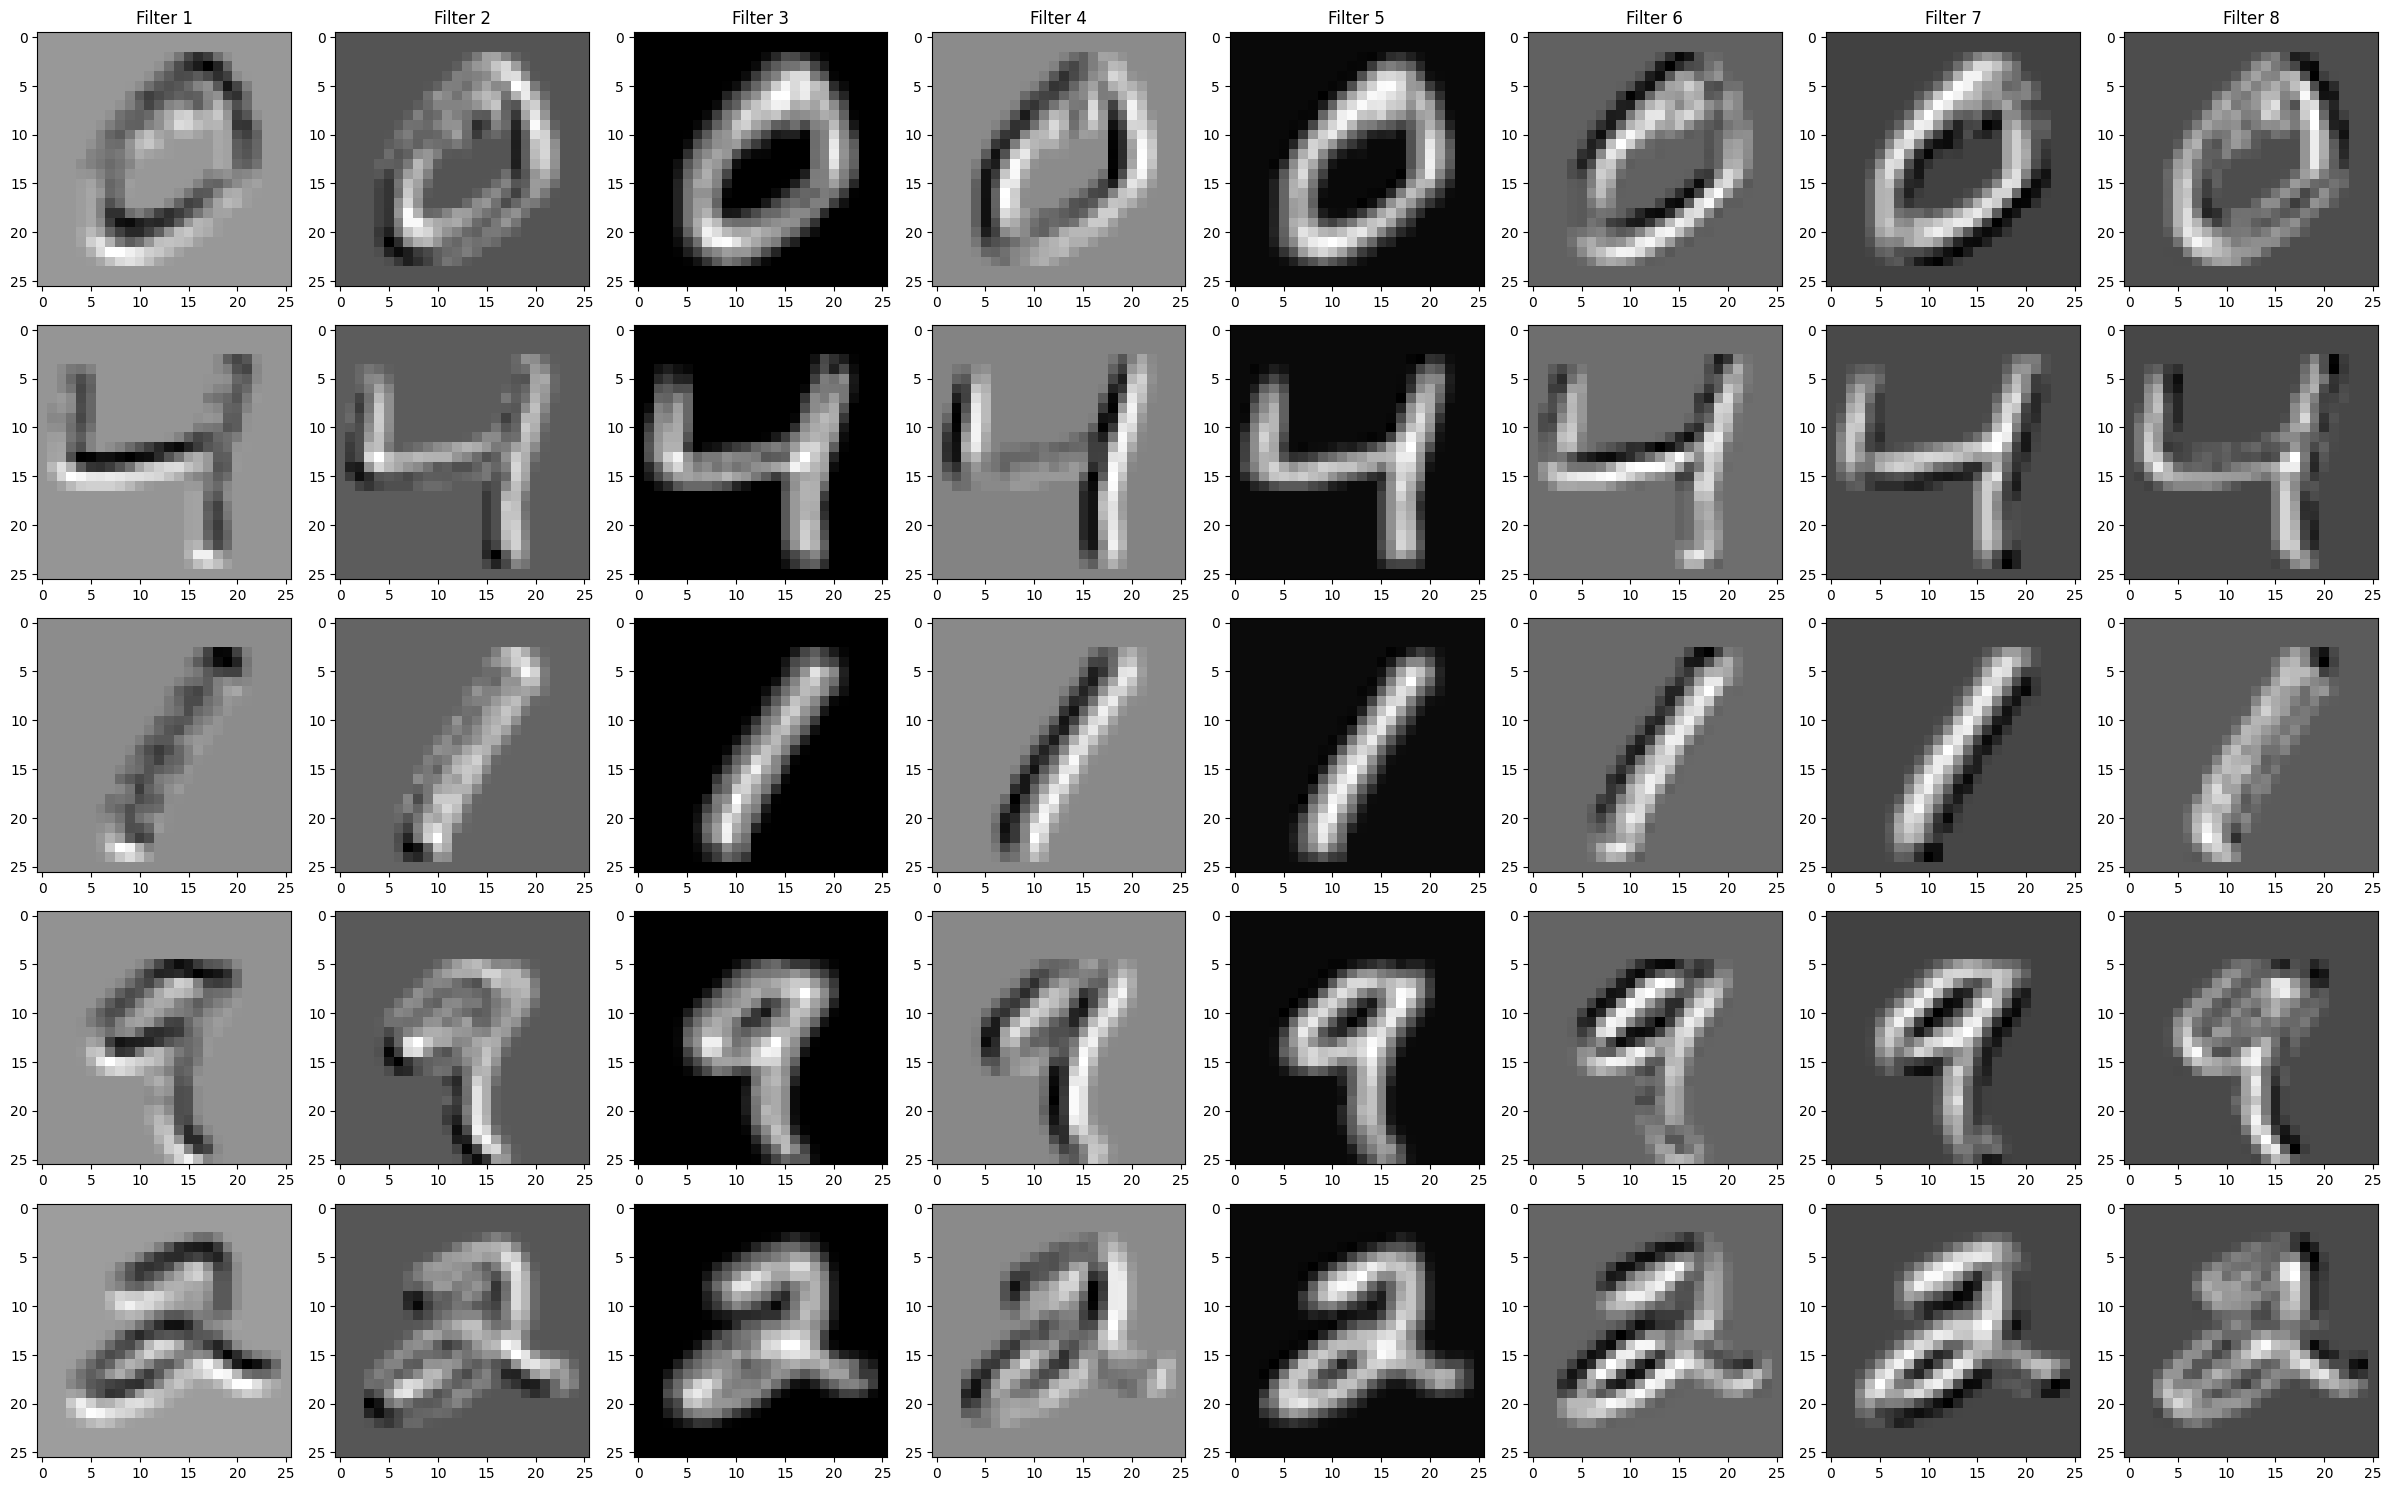

In [67]:
num_filterers = 8
filter_size = (3,3)
pool_size = (4,4)
model = keras.Sequential([
    Input(shape = (*Xtrain.shape[1:],1 )),
    Conv2D(num_filterers,filter_size,activation = "relu"),
    MaxPooling2D(pool_size = pool_size),
    Flatten(),
    Dense(10,activation = "softmax")
])
model.summary()
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss=keras.losses.CategoricalCrossentropy(),
              metrics=[keras.metrics.CategoricalAccuracy(name="accuracy")])
history = model.fit(Xtrain, Ytrain,
                    validation_split=0.15,
                    batch_size=128,
                    epochs=20,
                    shuffle=True)
plot_results(history)

conv_layer = next(layer for layer in model.layers if isinstance(layer, Conv2D))
w = conv_layer.get_weights()[0]

n_filters = w.shape[-1]
cols = min(8, n_filters)
rows = (n_filters + cols - 1) // cols
fig, ax = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
ax = np.array(ax).reshape(rows, cols)
for idx in range(n_filters):
    r = idx // cols
    c = idx % cols
    ax[r, c].imshow(w[:, :, 0, idx], cmap="gray")
    ax[r, c].set_title(f"Filter {idx+1}")

for idx in range(n_filters, rows*cols):
    r = idx // cols
    c = idx % cols
    ax[r, c].axis('off')
plt.tight_layout()

n_samples = min(5, Xtrain.shape[0])
cols = n_filters
rows = n_samples
fig, ax = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
for j in range(rows):
    for i in range(cols):
        filtered = apply_filter(Xtrain[j, :, :], w[:, :, 0, i])
        ax[j, i].imshow(filtered, cmap="gray")
        if j == 0:
            ax[j, i].set_title(f"Filter {i+1}")
plt.tight_layout()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 21, 21, 20)     │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 10, 10, 20)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 2000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │        20,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,310 (83.24 KB)

 Trainable params: 21,310 (83.24 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9045 - loss: 0.3535 - val_accuracy: 0.9632 - val_loss: 0.1346
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9684 - loss: 0.1127 - val_accuracy: 0.9758 - val_loss: 0.0831
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9771 - loss: 0.0777 - val_accuracy: 0.9780 - val_loss: 0.0726
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9816 - loss: 0.0622 - val_accuracy: 0.9830 - val_loss: 0.0597
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9844 - loss: 0.0523 - val_accuracy: 0.9852 - val_loss: 0.0535
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9860 - loss: 0.0465 - val_accuracy: 0.9836 - val_loss: 0.0564
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9876 - loss: 0.0409 - val_accuracy: 0.9846 - val_loss: 0.0539
Epoch 8/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9884 - loss: 0.0369 - val_accu

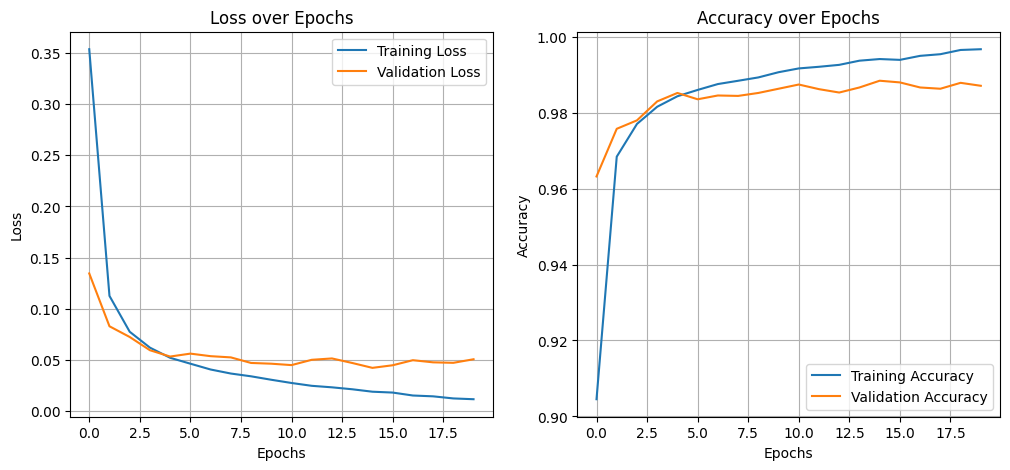

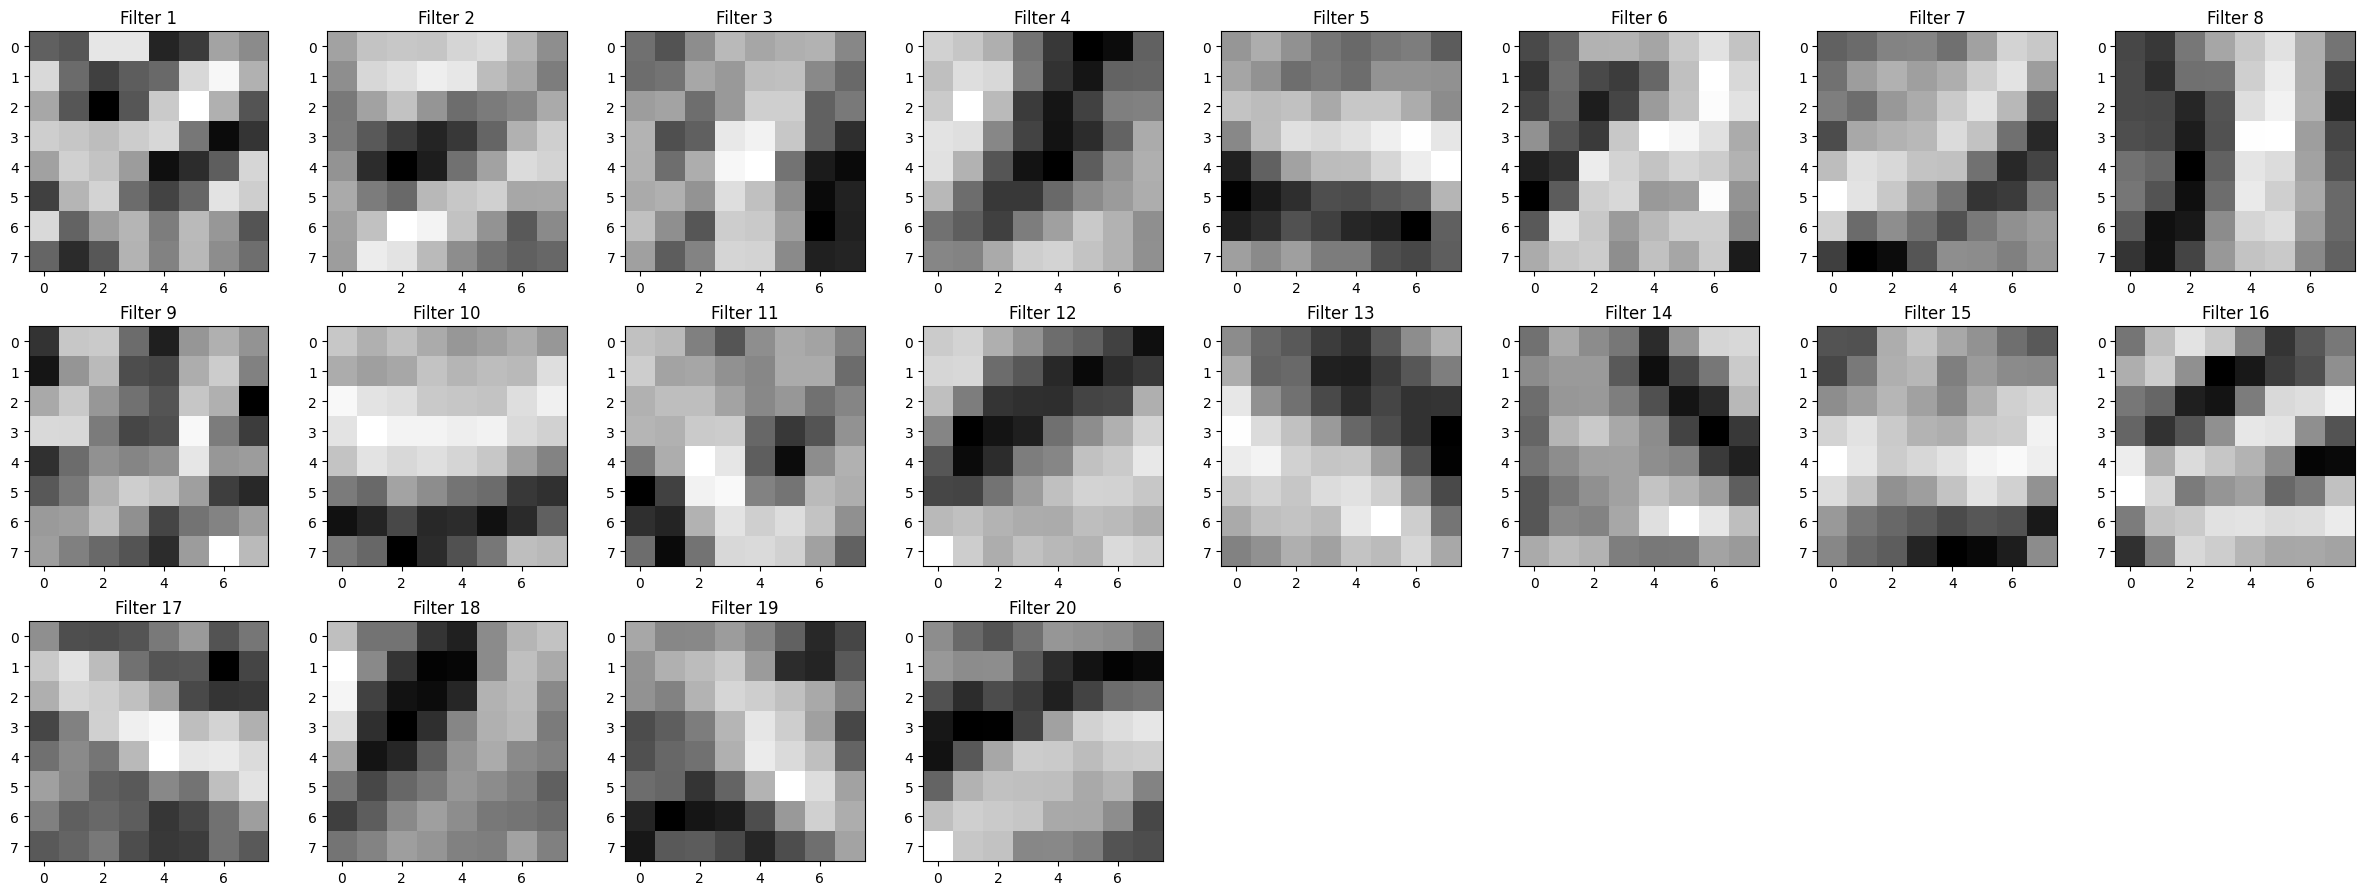

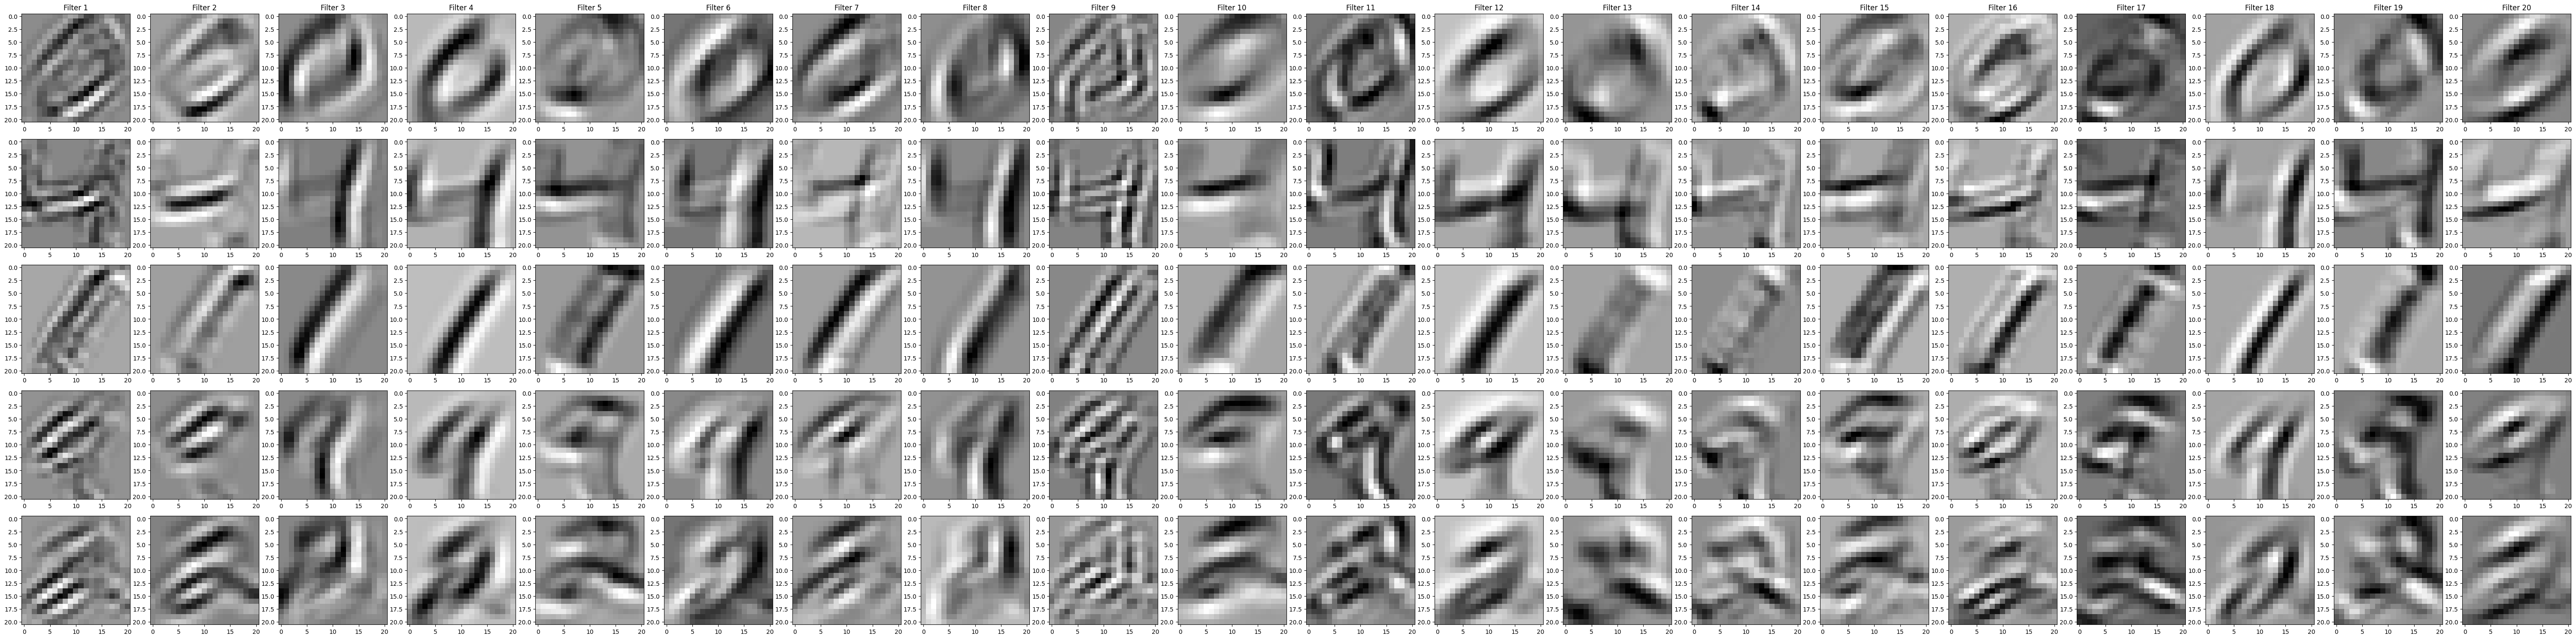

In [68]:
num_filterers = 20
filter_size = (8,8)
pool_size = (2,2)
model = keras.Sequential([
    Input(shape = (*Xtrain.shape[1:],1 )),
    Conv2D(num_filterers,filter_size,activation = "relu"),
    MaxPooling2D(pool_size = pool_size),
    Flatten(),
    Dense(10,activation = "softmax")
])
model.summary()
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss=keras.losses.CategoricalCrossentropy(),
              metrics=[keras.metrics.CategoricalAccuracy(name="accuracy")])
history = model.fit(Xtrain, Ytrain,
                    validation_split=0.15,
                    batch_size=128,
                    epochs=20,
                    shuffle=True)
plot_results(history)

conv_layer = next(layer for layer in model.layers if isinstance(layer, Conv2D))
w = conv_layer.get_weights()[0]

n_filters = w.shape[-1]
cols = min(8, n_filters)
rows = (n_filters + cols - 1) // cols
fig, ax = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
ax = np.array(ax).reshape(rows, cols)
for idx in range(n_filters):
    r = idx // cols
    c = idx % cols
    ax[r, c].imshow(w[:, :, 0, idx], cmap="gray")
    ax[r, c].set_title(f"Filter {idx+1}")
for idx in range(n_filters, rows*cols):
    r = idx // cols
    c = idx % cols
    ax[r, c].axis('off')
plt.tight_layout()

n_samples = min(5, Xtrain.shape[0])
cols = n_filters
rows = n_samples
fig, ax = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
for j in range(rows):
    for i in range(cols):
        filtered = apply_filter(Xtrain[j, :, :], w[:, :, 0, i])
        ax[j, i].imshow(filtered, cmap="gray")
        if j == 0:
            ax[j, i].set_title(f"Filter {i+1}")
plt.tight_layout()